# 01 — Group-Stage Error Analysis

A detailed audit of the 72 pre-tournament group-stage forecasts against the completed group-stage results. The notebook examines outcome accuracy, probability quality, exact-score performance, goal errors, confidence, group-level behavior, and the most important misses.

**Repository:** SambaSportAI World Cup 2026 Forecasting Pipeline  
**Execution:** Run from the repository root or directly from the `notebooks/` folder.  
**Reproducibility:** All inputs are read from version-controlled CSV/JSON artifacts in this repository.

In [1]:
from pathlib import Path
import json
import math
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    # Common fallback when launched from notebooks/ via Jupyter.
    fallback = Path.cwd().resolve().parent
    if (fallback / "pyproject.toml").exists():
        return fallback
    raise FileNotFoundError("Could not locate repository root. Launch Jupyter inside the repository.")

ROOT = find_repo_root()
print(f"Repository root: {ROOT}")

Repository root: /mnt/data/sambasportai-world-cup-2026


## 1. Load the prediction audit

The audit table is the canonical match-level file produced by `scripts/evaluate_group_stage.py`. It already joins each pre-tournament prediction with the observed result and derives outcome/score error columns.

In [2]:
audit_path = ROOT / "outputs" / "evaluation" / "group_stage_prediction_vs_actual.csv"
metrics_path = ROOT / "outputs" / "evaluation" / "group_stage_evaluation_metrics.json"

audit = pd.read_csv(audit_path)
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))

print(f"Matches: {len(audit)}")
display(audit.head(3))

Matches: 72


,group,date,date_display,home_team,away_team,city,country,neutral,p_home_win,p_draw,p_away_win,expected_goals_home,expected_goals_away,expected_score,predicted_exact_score,predicted_outcome,confidence_pct,top_scorelines,core_reasons,squad_reasons,ensemble_reasons,surprise_notes,squad_compare,pedigree_note,home_roster_note,away_roster_note,v8_strength_shift,model_version_note,actual_home_goals,actual_away_goals,source_name,source_url,actual_outcome,predicted_outcome_argmax,outcome_correct,actual_score,exact_score_correct,expected_score_correct,actual_total_goals,predicted_total_xg,total_goals_abs_error,home_goals_abs_error,away_goals_abs_error,within_one_goal_both,actual_over_2_5,pred_over_2_5,actual_btts,p_btts,pred_btts
0,A,2026-06-11,"Jun 11, 2026",Mexico,South Africa,Mexico City,Mexico,False,0.700868,0.188719,0.110414,2.882363,0.744440,3-1,2-0,home_win,51.214915,"[{""score"": ""2-0"", ""prob"": 0.11050115727898485}...","[{""feature"": ""elo_diff"", ""label"": ""Model ratin...","[{""feature"": ""hybrid_team_rating"", ""label"": ""H...","[{""feature"": ""ensemble_match_history"", ""label""...","[""Single-match surprises can still come from r...","[{""feature"": ""hybrid_team_rating"", ""label"": ""H...",the 2025 draw ranking favored Mexico (15 vs 61...,Guillermo Ochoa included for a sixth World Cup...,Final squad published; no specific additional ...,0.068474,v8 day-before roster-aware calibrated model: f...,2,0,FIFA-sourced 2026 World Cup results table,https://en.wikipedia.org/wiki/2026_FIFA_World_Cup,home_win,home_win,1,2-0,1,0,2,3.626803,1.626803,0.882363,0.744440,1,0,1,0,0.495599,0
1,A,2026-06-11,"Jun 11, 2026",South Korea,Czech Republic,Zapopan,Mexico,True,0.424387,0.262175,0.313438,1.797484,1.388660,2-1,1-1,home_win,11.094833,"[{""score"": ""1-1"", ""prob"": 0.1031659080757421},...","[{""feature"": ""elo_diff"", ""label"": ""Model ratin...","[{""feature"": ""hybrid_team_rating"", ""label"": ""H...","[{""feature"": ""ensemble_match_history"", ""label""...","[""This is still a volatile matchup: the model ...","[{""feature"": ""hybrid_team_rating"", ""label"": ""H...",the teams rated similarly in the blended model,Final squad includes dual-heritage addition Je...,Final squad published; no specific additional ...,0.029821,v8 day-before roster-aware calibrated model: f...,2,1,FIFA-sourced 2026 World Cup results table,https://en.wikipedia.org/wiki/2026_FIFA_World_Cup,home_win,home_win,1,2-1,0,1,3,3.186144,0.186144,0.202516,0.388660,1,1,1,1,0.626206,1
2,A,2026-06-18,"Jun 18, 2026",Czech Republic,South Africa,Atlanta,United States,True,0.430057,0.267352,0.302591,1.776117,1.362997,2-1,1-1,home_win,12.746651,"[{""score"": ""1-1"", ""prob"": 0.10487367820010825}...","[{""feature"": ""elo_diff"", ""label"": ""Model ratin...","[{""feature"": ""rank_elo_equiv"", ""label"": ""Histo...","[{""feature"": ""ensemble_match_history"", ""label""...","[""An upset is still plausible: South Africa ke...","[{""feature"": ""hybrid_team_rating"", ""label"": ""H...",Czech Republic had the stronger long-run World...,Final squad published; no specific additional ...,Final squad published; no specific additional ...,-0.022307,v8 day-before roster-aware calibrated model: f...,1,1,FIFA-sourced 2026 World Cup results table,https://en.wikipedia.org/wiki/2026_FIFA_World_Cup,draw,home_win,0,1-1,1,0,2,3.139115,1.139115,0.776117,0.362997,1,0,1,1,0.618134,1


## 2. Headline metrics

In [3]:
headline_keys = [
    "matches",
    "outcome_accuracy",
    "majority_class_baseline_accuracy",
    "accuracy_gain_over_baseline",
    "log_loss",
    "multiclass_brier_score",
    "ranked_probability_score",
    "expected_calibration_error",
    "exact_score_accuracy",
    "rounded_expected_score_accuracy",
    "home_goal_mae",
    "away_goal_mae",
    "total_goals_mae",
    "over_2_5_accuracy",
    "both_teams_to_score_accuracy",
]
available = {k: metrics.get(k) for k in headline_keys if k in metrics}
headline = pd.DataFrame({"metric": available.keys(), "value": available.values()})
display(headline)

,metric,value
0,outcome_accuracy,0.597222
1,log_loss,0.879911
2,multiclass_brier_score,0.520571
3,ranked_probability_score,0.159352
4,exact_score_accuracy,0.111111
5,rounded_expected_score_accuracy,0.055556
6,total_goals_mae,1.640246
7,over_2_5_accuracy,0.555556


## 3. Outcome confusion matrix and class recall

Predicted,home_win,draw,away_win
Actual,,,
home_win,26,0,7
draw,13,0,7
away_win,2,0,17


,recall
home_win,0.787879
draw,0.000000
away_win,0.894737


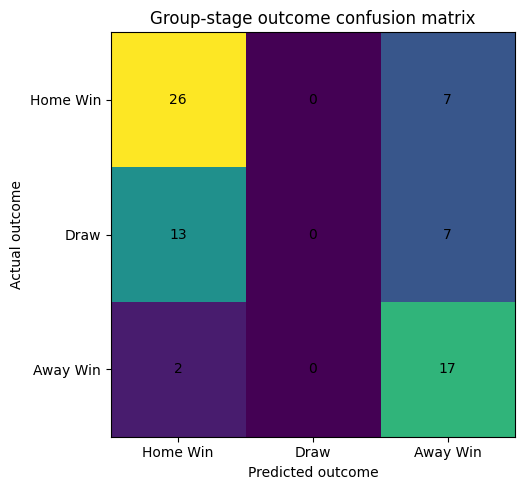

In [4]:
outcome_order = ["home_win", "draw", "away_win"]
confusion = pd.crosstab(
    pd.Categorical(audit["actual_outcome"], categories=outcome_order),
    pd.Categorical(audit["predicted_outcome_argmax"], categories=outcome_order),
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False,
)
display(confusion)

recalls = {}
for outcome in outcome_order:
    mask = audit["actual_outcome"] == outcome
    recalls[outcome] = (audit.loc[mask, "predicted_outcome_argmax"] == outcome).mean() if mask.any() else np.nan
display(pd.Series(recalls, name="recall").to_frame())

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion.values)
ax.set_xticks(range(len(outcome_order)), [x.replace("_", " ").title() for x in outcome_order])
ax.set_yticks(range(len(outcome_order)), [x.replace("_", " ").title() for x in outcome_order])
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")
ax.set_title("Group-stage outcome confusion matrix")
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, int(confusion.iloc[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

## 4. Performance by group

,matches,outcome_accuracy,exact_score_accuracy,expected_score_accuracy,home_goal_mae,away_goal_mae,total_goals_mae,mean_confidence
group,,,,,,,,
I,6,1.000,0.167,0.000,0.918,0.898,1.395,34.793
C,6,0.833,0.167,0.000,0.944,0.837,1.656,40.005
J,6,0.833,0.167,0.167,0.635,0.624,1.139,37.694
A,6,0.667,0.333,0.167,0.671,0.920,1.289,28.201
L,6,0.667,0.000,0.000,1.329,1.005,2.269,37.823
B,6,0.667,0.000,0.000,1.330,0.563,1.333,29.589
F,6,0.500,0.000,0.167,1.392,0.626,1.409,32.511
E,6,0.500,0.333,0.167,1.530,0.836,2.039,35.441
K,6,0.500,0.000,0.000,1.402,0.868,1.713,28.527


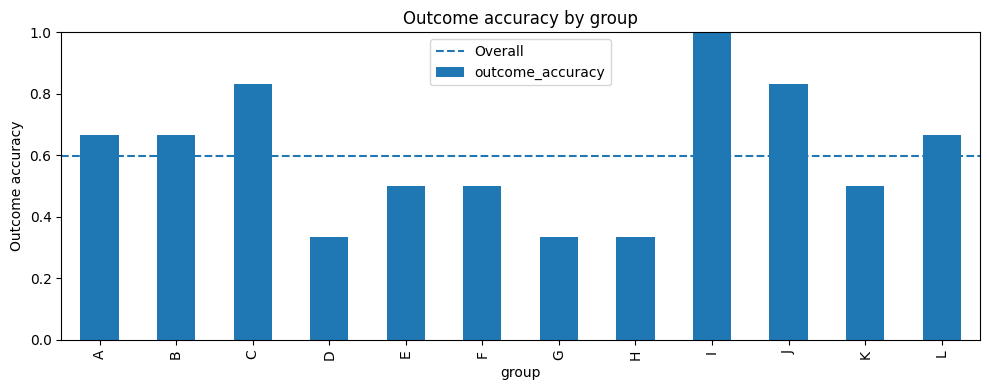

In [5]:
by_group = (
    audit.groupby("group")
    .agg(
        matches=("outcome_correct", "size"),
        outcome_accuracy=("outcome_correct", "mean"),
        exact_score_accuracy=("exact_score_correct", "mean"),
        expected_score_accuracy=("expected_score_correct", "mean"),
        home_goal_mae=("home_goals_abs_error", "mean"),
        away_goal_mae=("away_goals_abs_error", "mean"),
        total_goals_mae=("total_goals_abs_error", "mean"),
        mean_confidence=("confidence_pct", "mean"),
    )
    .sort_values("outcome_accuracy", ascending=False)
)
display(by_group.round(3))

ax = by_group["outcome_accuracy"].sort_index().plot(kind="bar", figsize=(10, 4))
ax.axhline(audit["outcome_correct"].mean(), linestyle="--", label="Overall")
ax.set_ylim(0, 1)
ax.set_ylabel("Outcome accuracy")
ax.set_title("Outcome accuracy by group")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Accuracy as a function of confidence

,matches,mean_confidence,outcome_accuracy,log_loss_proxy,total_goals_mae
confidence_quartile,,,,,
"(1.092, 15.351]",18,8.342,0.389,NaN,1.765
"(15.351, 33.262]",18,26.948,0.556,NaN,1.478
"(33.262, 45.435]",18,38.389,0.667,NaN,1.398
"(45.435, 65.621]",18,53.699,0.778,NaN,1.920


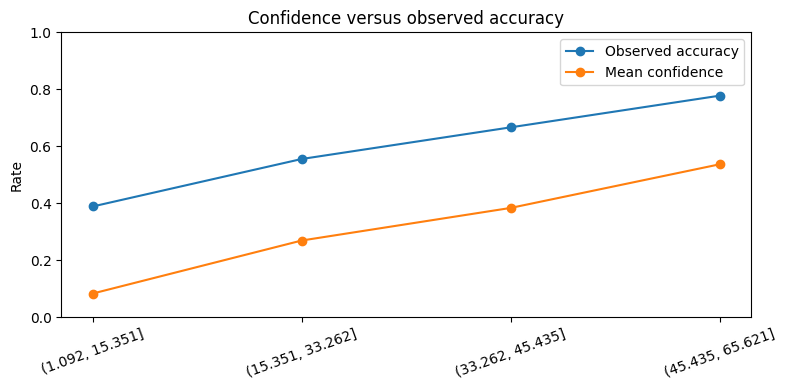

In [6]:
audit = audit.copy()
# qcut can collapse duplicate boundaries; duplicates='drop' keeps this robust.
audit["confidence_quartile"] = pd.qcut(audit["confidence_pct"], q=4, duplicates="drop")
confidence_summary = (
    audit.groupby("confidence_quartile", observed=True)
    .agg(
        matches=("outcome_correct", "size"),
        mean_confidence=("confidence_pct", "mean"),
        outcome_accuracy=("outcome_correct", "mean"),
        log_loss_proxy=("outcome_correct", lambda s: np.nan),
        total_goals_mae=("total_goals_abs_error", "mean"),
    )
)
display(confidence_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(confidence_summary))
ax.plot(x, confidence_summary["outcome_accuracy"].values, marker="o", label="Observed accuracy")
ax.plot(x, confidence_summary["mean_confidence"].values / 100.0, marker="o", label="Mean confidence")
ax.set_xticks(x, [str(v) for v in confidence_summary.index], rotation=20)
ax.set_ylim(0, 1)
ax.set_ylabel("Rate")
ax.set_title("Confidence versus observed accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Score and goals error analysis

,value
exact_score_accuracy,0.1111
rounded_expected_score_accuracy,0.0556
home_goal_mae,1.0968
away_goal_mae,0.8866
total_goals_mae,1.6402
within_one_goal_both,0.3056
over_2_5_accuracy,0.5556
btts_accuracy,0.5556


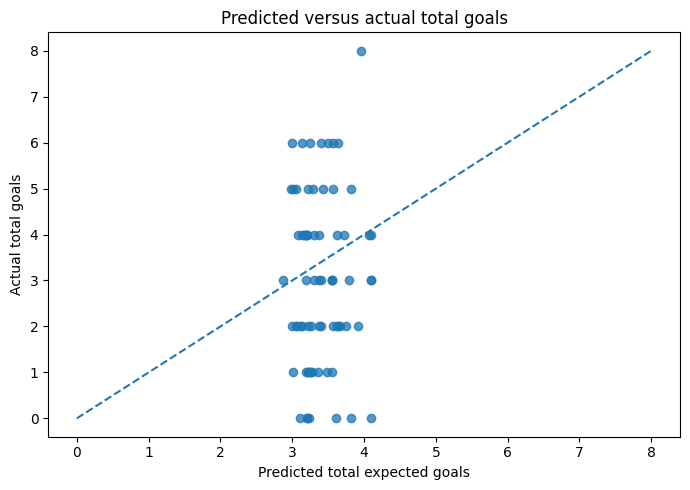

In [7]:
score_metrics = pd.Series({
    "exact_score_accuracy": audit["exact_score_correct"].mean(),
    "rounded_expected_score_accuracy": audit["expected_score_correct"].mean(),
    "home_goal_mae": audit["home_goals_abs_error"].mean(),
    "away_goal_mae": audit["away_goals_abs_error"].mean(),
    "total_goals_mae": audit["total_goals_abs_error"].mean(),
    "within_one_goal_both": audit["within_one_goal_both"].mean(),
    "over_2_5_accuracy": (audit["actual_over_2_5"] == audit["pred_over_2_5"]).mean(),
    "btts_accuracy": (audit["actual_btts"] == audit["pred_btts"]).mean(),
}, name="value")
display(score_metrics.to_frame().round(4))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(audit["predicted_total_xg"], audit["actual_total_goals"], alpha=0.75)
min_v = min(audit["predicted_total_xg"].min(), audit["actual_total_goals"].min())
max_v = max(audit["predicted_total_xg"].max(), audit["actual_total_goals"].max())
ax.plot([min_v, max_v], [min_v, max_v], linestyle="--")
ax.set_xlabel("Predicted total expected goals")
ax.set_ylabel("Actual total goals")
ax.set_title("Predicted versus actual total goals")
plt.tight_layout()
plt.show()

## 7. Largest result and score misses

In [8]:
audit["actual_outcome_probability"] = np.select(
    [
        audit["actual_outcome"] == "home_win",
        audit["actual_outcome"] == "draw",
        audit["actual_outcome"] == "away_win",
    ],
    [audit["p_home_win"], audit["p_draw"], audit["p_away_win"]],
    default=np.nan,
)
audit["surprise_score"] = -np.log(np.clip(audit["actual_outcome_probability"], 1e-12, 1.0))

columns = [
    "group", "home_team", "away_team", "actual_score", "predicted_exact_score",
    "expected_score", "predicted_outcome_argmax", "actual_outcome",
    "actual_outcome_probability", "confidence_pct", "total_goals_abs_error", "surprise_score"
]
display(audit.sort_values("surprise_score", ascending=False)[columns].head(12).round(3))

,group,home_team,away_team,actual_score,predicted_exact_score,expected_score,predicted_outcome_argmax,actual_outcome,actual_outcome_probability,confidence_pct,total_goals_abs_error,surprise_score
43,H,Spain,Cape Verde,0-0,3-0,3-1,home_win,draw,0.152,64.726,4.100,1.884
68,L,England,Ghana,0-0,3-0,3-1,home_win,draw,0.177,55.192,3.814,1.734
26,E,Ecuador,Curaçao,0-0,2-0,3-1,home_win,draw,0.196,48.159,3.603,1.630
7,B,Qatar,Switzerland,1-1,0-2,1-3,away_win,draw,0.200,46.356,1.571,1.610
45,H,Uruguay,Cape Verde,2-2,2-0,3-1,home_win,draw,0.206,44.955,0.383,1.581
60,K,Portugal,DR Congo,1-1,2-0,3-1,home_win,draw,0.215,43.536,1.662,1.535
6,B,Canada,Bosnia and Herzegovina,1-1,2-0,2-1,home_win,draw,0.221,34.248,1.068,1.508
42,H,Saudi Arabia,Uruguay,1-1,0-2,1-2,away_win,draw,0.223,38.261,1.368,1.501
29,E,Ecuador,Germany,2-1,1-2,1-2,away_win,home_win,0.224,25.163,0.368,1.495
5,A,South Africa,South Korea,1-0,1-1,1-2,away_win,home_win,0.235,26.582,2.222,1.448


## 8. Draw-specific diagnosis

In [9]:
draw_matches = audit[audit["actual_outcome"] == "draw"].copy()
draw_summary = pd.Series({
    "actual_draws": len(draw_matches),
    "draw_argmax_predictions": (audit["predicted_outcome_argmax"] == "draw").sum(),
    "draw_recall": (draw_matches["predicted_outcome_argmax"] == "draw").mean(),
    "mean_draw_probability_on_actual_draws": draw_matches["p_draw"].mean(),
    "median_draw_probability_on_actual_draws": draw_matches["p_draw"].median(),
    "max_draw_probability": audit["p_draw"].max(),
}, name="value")
display(draw_summary.to_frame())

display(
    draw_matches[["home_team", "away_team", "actual_score", "p_home_win", "p_draw", "p_away_win", "predicted_outcome_argmax"]]
    .sort_values("p_draw", ascending=False)
    .head(12)
    .round(3)
)

,value
actual_draws,20.000000
draw_argmax_predictions,0.000000
draw_recall,0.000000
mean_draw_probability_on_actual_draws,0.233902
median_draw_probability_on_actual_draws,0.236771
max_draw_probability,0.275869


,home_team,away_team,actual_score,p_home_win,p_draw,p_away_win,predicted_outcome_argmax
46,Cape Verde,Saudi Arabia,0-0,0.323,0.276,0.402,away_win
64,Colombia,Portugal,0-0,0.314,0.270,0.416,away_win
22,Paraguay,Australia,0-0,0.346,0.269,0.385,away_win
2,Czech Republic,South Africa,1-1,0.430,0.267,0.303,home_win
40,Egypt,Iran,1-1,0.288,0.262,0.450,away_win
58,Algeria,Austria,3-3,0.321,0.260,0.418,away_win
30,Netherlands,Japan,2-2,0.527,0.259,0.213,home_win
38,Belgium,Iran,0-0,0.515,0.258,0.227,home_win
12,Brazil,Morocco,1-1,0.515,0.257,0.228,home_win
34,Japan,Sweden,1-1,0.571,0.238,0.190,home_win


## Conclusions

The principal findings should match the project report:

- The model was substantially better at identifying home and away wins than draws.
- Tournament-level ranking/qualification forecasts were stronger than exact-score forecasts.
- The most useful next modeling target is a better draw/calibration layer rather than simply increasing model complexity.
- Goal prediction should be evaluated with MAE and distributional scores, not only exact-score accuracy.